### Stochastic interpolant demo with **equivariant OT**: uniform angles → 1D XY chain

A minimal model for 1D classical XY chains using an interpolant that
pairs base and target with the **Z₂ × U(1) equivariant-OT coupling**.

- `load_mc_data` — build the target dataset (XY-chain Monte Carlo samples).
- `sample_base`  — the prior sampler `p₀`: i.i.d. uniform angles on `(-π, π]`.
- `make_model`   — an `xyEESI` wrapping two `XYChainGNN`s (drift + score).
- `xy_step` / `train` — one coupled step / the full loop. The coupling
  (`eesi.ot.xy_ot_couple`) runs under `no_grad` and just re-pairs the batch before
  `model.loss`, so nothing about the interpolant changes.

The coupling has two independent layers, toggled per call: `align` (OT over the
symmetry group Z₂ × U(1)), `batch` (minibatch OT over the batch), and `reflect`
(include the Z₂ reflection, vs. U(1) only). See `eesi/ot.py`.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import iv

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

# The new training hooks: dataset + sampler + model + coupled training step/loop.
from eesi.systems.xy.train import load_exact_data, sample_base, make_model, train
from eesi.systems.xy.ot import xy_ot_couple
from eesi.systems.xy.gnn import angle_wrap

%matplotlib inline
torch.seed()
np.random.seed()
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x, J):              # E = -J * sum_i cos(dtheta_i)
    return (-J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

### 1. Datasets & samplers

`load_mc_data` runs the Metropolis Monte Carlo sampler `eesi.datasets.xy.mcxy` and wraps the
angles onto `(-π, π]` which is the fixed **target** `p₁`. `sample_base` is the
**base** `p₀`: i.i.d. uniform angles, drawn each step. Both are Z₂ × U(1)
invariant, which is what makes the equivariant-OT coupling marginal-preserving.

We use a tiny `N = 10` chain to exercise the pipeline end-to-end.

In [3]:
N = 10           # chain length
J = 2.0          # ferromagnetic coupling of the target Boltzmann distribution

x1_all = load_exact_data(N,J,10_000,seed=8).to(device)
n_data = x1_all.shape[0]
print("target dataset:", tuple(x1_all.shape))
print("sampled energy:", chain_energy(x1_all, J).mean().round(3)/N)

# Exact per-spin energy change (I_1/I_0 Bessel ratio) for reference.
dE = (N - 1) * (-J * (iv(1, J) / iv(0, J))) / N
print(f"exact energy  : {dE:+.4f}  (per spin)")

target dataset: (10000, 10)
sampled energy: -1.2559
exact energy  : -1.2560  (per spin)


### 2. Model & sampler setup (via `make_model`)

`make_model` returns an `xyEESI` wrapping two chain-length-independent
`XYChainGNN`s (drift `net_b` and score `net_s`); the interpolant `path`/`gamma`
schedules are passed straight through. Extra `xyEESI` kwargs (`d`,
`score_div_method`, …) go via `**kw`.

In [ ]:
# Changing the batch size changes the x0/x1 coupling distribution and therefore
# the time-dependent marginals. So it's important to keep this constant across
# training and sampling.
batch_size = 256
torch.manual_seed(6)

# Model definition
model = make_model(
    n_neighbors=2, hidden=16, mlp_layers=3, n_layers=3, edge_order=8, time_order=8,
    path="linear", gamma="sqrt", gamma_scale=0.2,
    score_div_method="exact",
).to(device)
print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

#model.net_b.load_state_dict(torch.load('xy_b_N10_B256.pth',weights_only=True))
#model.net_s.load_state_dict(torch.load('xy_s_N10_B256.pth',weights_only=True))


net_b params: 3488
net_s params: 3488


### 3. Training with equivariant OT

`train` runs the coupled loop: each step draws a target minibatch and a fresh base
batch, applies `xy_ot_couple` (the flags below), and minimises the drift + score
losses. Setting `align`, `batch_ot`, `reflect` all `True` is the **full Z₂ × U(1)
equivariant-OT** coupling; the logged `transport` cost drops relative to random
pairing. Flip any flag off for the ablation arms (e.g. `align=False` = plain
minibatch OT, `reflect=False` = U(1) only).

In [5]:

model, total_hist = train(
    x1_all, model=model,
    steps=2_000, batch=batch_size, lr=1e-4, batch_ot=False,
    device=str(device), seed=0, log_every=100
)

model, hist = train(
    x1_all, model=model,
    steps=3_000, batch=batch_size, lr=3e-4,batch_ot=False,
    device=str(device), seed=0, log_every=1000
)
total_hist += hist

model, hist = train(
    x1_all, model=model,
    steps=10_000, batch=batch_size, lr=1e-4,batch_ot=False,
    device=str(device), seed=0, log_every=1000
)
total_hist += hist



#torch.save(model.net_b.state_dict(), './xy_b_N10_B256.pth')
#torch.save(model.net_s.state_dict(), './xy_s_N10_B256.pth')


  step     0  loss_b    0.0017  loss_s   -0.0021  transport   5.902  (  0.7s)
  step   100  loss_b   -0.3029  loss_s   -0.3066  transport   5.893  (  2.8s)
  step   200  loss_b   -0.9901  loss_s   -1.0316  transport   5.788  (  4.8s)
  step   300  loss_b   -1.6867  loss_s   -1.7939  transport   5.855  (  6.7s)
  step   400  loss_b   -2.0351  loss_s   -2.2332  transport   5.888  (  8.6s)
  step   500  loss_b   -2.1553  loss_s   -2.3916  transport   5.812  ( 10.4s)
  step   600  loss_b   -2.1874  loss_s   -2.7491  transport   5.813  ( 12.2s)
  step   700  loss_b   -2.2615  loss_s   -3.2101  transport   5.976  ( 14.1s)
  step   800  loss_b   -2.3358  loss_s   -3.3861  transport   5.850  ( 16.1s)
  step   900  loss_b   -2.3528  loss_s   -3.4069  transport   5.839  ( 18.1s)
  step  1000  loss_b   -2.4302  loss_s   -3.4744  transport   5.836  ( 20.0s)
  step  1100  loss_b   -2.4568  loss_s   -3.4578  transport   5.782  ( 21.9s)
  step  1200  loss_b   -2.4660  loss_s   -3.4810  transport   5.

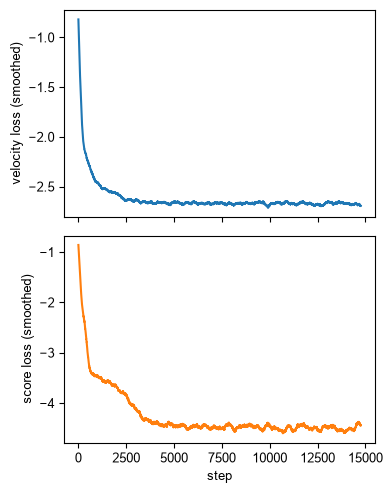

In [6]:
# Training curves (smoothed).
def smooth(v, k=250):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

hist_b, hist_s = map(np.asarray, zip(*total_hist))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the built-in samplers (inherited unchanged from `EESI`):
`sample_ode` integrates the probability-flow ODE `dx/dt = b(t, x)`; `sample_sde`
integrates the reverse-time SDE using both `b` and `s`. We compare two physical
observables of generated vs. true configurations: the wrapped nearest-neighbour
angle difference Δθ and the per-chain energy `E = J Σ cos Δθ`.

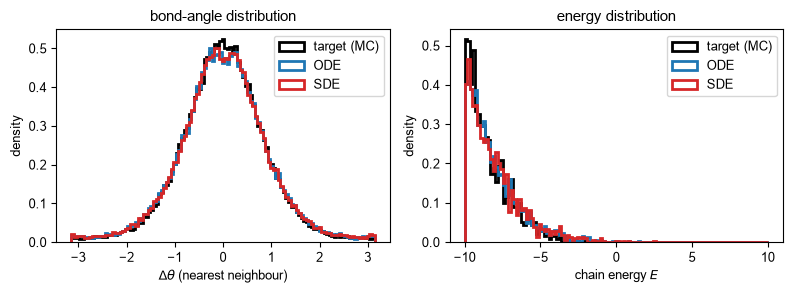

target (MC)   <E> = -12.5588   std(E) = 2.4397
ODE           <E> = -12.1743   std(E) = 2.5756
SDE           <E> = -12.1686   std(E) = 2.6190
Exact         <E> = -12.5599


In [8]:
torch.manual_seed(19)
n_gen = 10_000
x0 = sample_base(n_gen, N, device=device)
gen_ode = model.sample(x0, n_steps=100)             # probability-flow ODE (drift only)
gen_sde = model.sample(x0, n_steps=100, eps=0.1)    # reverse-time SDE (drift + score)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bins = np.linspace(-np.pi, np.pi, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[0].hist(dtheta(x), bins=bins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[0].set_xlabel(r"$\Delta\theta$ (nearest neighbour)"); ax[0].set_ylabel("density")
ax[0].set_title("bond-angle distribution"); ax[0].legend()

ebins = np.linspace(-N, N, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[1].hist(chain_energy(x, J), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].set_xlabel("chain energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend()
plt.tight_layout()
plt.show()

for x, lbl in [(x1_all, "target (MC)"), (gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x, J)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")
print(f"{'Exact':12s}  <E> = {(N - 1) * (-J * (iv(1, J) / iv(0, J))):+.4f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways
(all inherited from `EESI`): `entropy_estimate_dot` (mean of $-b\cdot s$),
`entropy_estimate_div` (mean of $\nabla\!\cdot b$, score-free), and the running
ODE path integral from `sample_ode_entropy_traj`. Compared against the exact
$\Delta S = (N-1)\,[\log I_0(J) - J\,I_1(J)/I_0(J)]$.

entropy estimate (b·z)   : -5.0541 ± 0.0694
entropy estimate (b·s)   : -5.0034 ± 0.0418
entropy estimate (div b) : -5.2451 ± 0.0366
entropy estimate (ODE div): -5.0756 ± 0.0271
entropy estimate (ODE dot): -4.7951 ± 0.0238
exact entropy: -5.1440


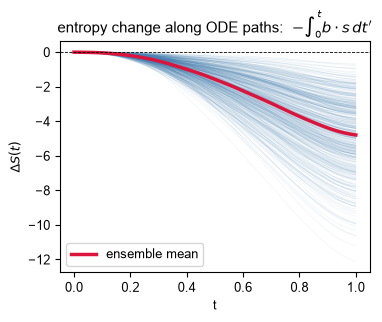

In [9]:
torch.manual_seed(1414)
n_batches = 100
means_dot, means_div, means_zdot = [], [], []
x1_all.to(device)

for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch_size, N, device=device)
    x0, x1 = xy_ot_couple(x0, x1, batch=False)
    means_dot.append(model.entropy_estimate(x1, x0, "dot").mean().item())
    means_div.append(model.entropy_estimate(x1, x0, "div").mean().detach().item())
    means_zdot.append(model.entropy_estimate(x1, x0, "zdot").mean().item())

print(f"entropy estimate (b·z)   : {np.mean(means_zdot):+.4f} ± {1.96*np.std(means_zdot)/np.sqrt(n_batches):.4f}")
print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.4f} ± {1.96*np.std(means_dot)/np.sqrt(n_batches):.4f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.4f} ± {1.96*np.std(means_div)/np.sqrt(n_batches):.4f}")

# Running entropy change along many ODE paths.
n_batches = 100
npath = batch_size*n_batches
x0 = sample_base(npath, N, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=100, return_traj=True, entropy="div")
ts_c, ent_c_div = ts.cpu().numpy(), ent_traj.cpu().numpy()
ent_c_avg = ent_c_div[-1,:].reshape(n_batches,-1).mean(-1)
print(f"entropy estimate (ODE div): {ent_c_avg.mean():+.4f} ± {1.96*ent_c_avg.std()/np.sqrt(n_batches):.4f}")
traj, ent_traj, ts = model.sample(x0, n_steps=100, return_traj=True, entropy="dot")
ts_c, ent_c_dot = ts.cpu().numpy(), ent_traj.cpu().numpy()
ent_c_avg = ent_c_dot[-1,:].reshape(n_batches,-1).mean(-1)
print(f"entropy estimate (ODE dot): {ent_c_avg.mean():+.4f} ± {1.96*ent_c_avg.std()/np.sqrt(n_batches):.4f}")

dS = (N - 1) * (np.log(iv(0, J)) - J * (iv(1, J) / iv(0, J)))
print(f"exact entropy: {dS:+.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c_dot[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

In [45]:
torch.manual_seed(1476)
n_batches = 50
eesi_dot, eesi_div, eesi_zdot = [], [], []
x1_all.to(device)

for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch_size, N, device=device)
    x0, x1 = xy_ot_couple(x0, x1, batch=False)
    eesi_dot.append(model.entropy_estimate(x1, x0, "dot").cpu().numpy())
    eesi_div.append(model.entropy_estimate(x1, x0, "div").detach().cpu().numpy())
    eesi_zdot.append(model.entropy_estimate(x1, x0, "zdot").cpu().numpy())

eesi_dot = np.array(eesi_dot).flatten()
eesi_div = np.array(eesi_div).flatten()
eesi_zdot = np.array(eesi_zdot).flatten()

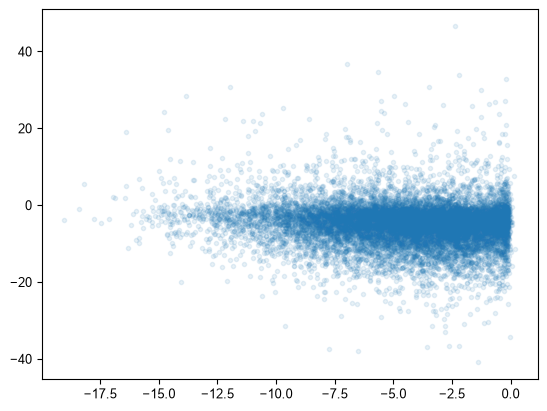

In [46]:
plt.scatter(eesi_dot, eesi_zdot,marker='.',alpha=0.1)
plt.show()

In [47]:
import scipy.stats
print(scipy.stats.pearsonr(eesi_dot, eesi_div))
print(scipy.stats.pearsonr(eesi_zdot, eesi_div))
print(scipy.stats.pearsonr(eesi_dot, eesi_zdot))

PearsonRResult(statistic=np.float64(-0.17251719696269308), pvalue=np.float64(4.405732790499908e-86))
PearsonRResult(statistic=np.float64(0.18738871225001366), pvalue=np.float64(1.718387492206989e-101))
PearsonRResult(statistic=np.float64(-0.11074967653923015), pvalue=np.float64(3.1925797856893454e-36))


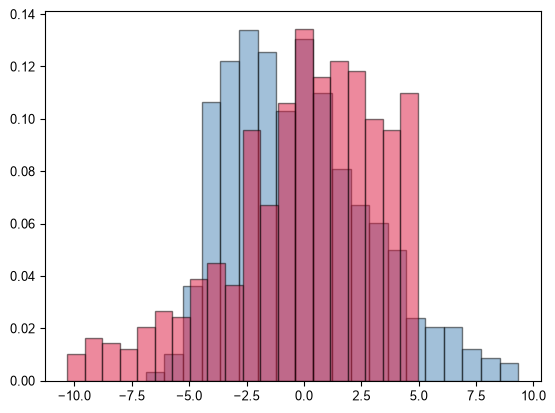

In [48]:
thresh = -5.0
idx = np.where(np.isclose(eesi_dot,thresh,rtol=5e-2))[0]
plt.hist(eesi_div[idx]-thresh,bins=20,edgecolor='black',density=True,color='steelblue',alpha=0.5)

idx = np.where(np.isclose(eesi_div,thresh,rtol=5e-2))[0]
plt.hist(eesi_dot[idx]-thresh,bins=20,edgecolor='black',density=True,color='crimson',alpha=0.5)

plt.show()





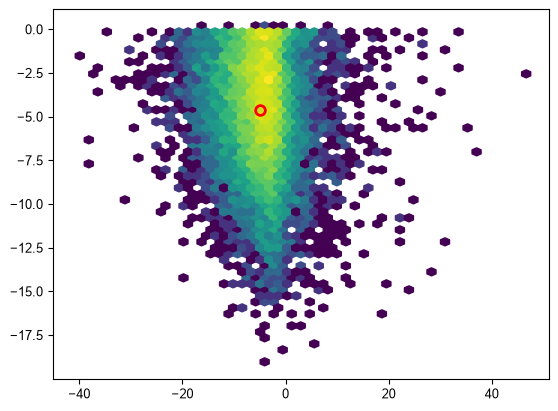

In [49]:
plt.hexbin(eesi_zdot,eesi_dot,bins='log',gridsize=50)
plt.plot(np.mean(eesi_zdot),np.mean(eesi_dot),'ro',mew=2,mfc='none',ms=7)
plt.show()






In [33]:
torch.manual_seed(100)
n_gen = 10_000
x0 = sample_base(n_gen, N, device=device)
x1_gen = model.sample(x0, n_steps=50)    

means_dot, means_div, means_zdot = [], [], []
n_batches = 100
for _ in range(n_batches):
    idx = torch.randint(0, n_gen, (batch_size,), device=device)
    x1 = x1_gen[idx]
    x0 = sample_base(batch_size, N, device=device)
    x0, x1 = xy_ot_couple(x0, x1, batch=False)
    means_dot.append(model.entropy_estimate(x1, x0, "dot").mean().item())
    means_div.append(model.entropy_estimate(x1, x0, "div").mean().detach().item())
    means_zdot.append(model.entropy_estimate(x1, x0, "zdot").mean().item())

print(f"entropy estimate (b·z)   : {np.mean(means_zdot):+.4f} ± {1.96*np.std(means_zdot)/np.sqrt(n_batches):.4f}")
print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.4f} ± {1.96*np.std(means_dot)/np.sqrt(n_batches):.4f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.4f} ± {1.96*np.std(means_div)/np.sqrt(n_batches):.4f}")


entropy estimate (b·z)   : -4.8505 ± 0.0702
entropy estimate (b·s)   : -4.8481 ± 0.0424
entropy estimate (div b) : -5.0959 ± 0.0370


#### Save the models

In [82]:
torch.save(model.net_b.state_dict(), './xy_b_N10_B256.pth')
torch.save(model.net_s.state_dict(), './xy_s_N10_B256.pth')

### 6. Other Values of N

In [111]:
chain_lengths   = np.array([1,2,4,8,16,32,64])
energies        = np.zeros_like(chain_lengths,dtype=np.float64)
entropies       = np.zeros_like(chain_lengths,dtype=np.float64)

n_gen = 1_000

for i,chain_length in enumerate(chain_lengths):
    print(chain_length)
    # sample base distribution and integrate, accumulating entropy
    x0 = sample_base(n_gen, chain_length, device=device)
    x1, ent = model.sample(x0, n_steps=50, entropy="dot")
    energies[i] = chain_energy(x1, J).mean()/float(chain_length)
    entropies[i] = ent.cpu().numpy().mean()/float(chain_length)

free_energies = energies - entropies


1
2
4
8
16
32
64


In [112]:
print(x1.shape)
d = torch.cos(angle_wrap(x1[...,1:] - x1[...,:-1]))
corr = d[...,1:] * d[...,:-1]
cov = corr.mean(-1) - d.mean()**2
cov.mean()

torch.Size([1000, 64])


tensor(0.0119, device='cuda:0')

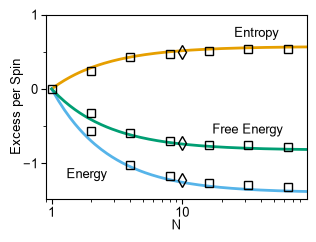

[0.19201686 0.02425591 0.0359144  0.03589592 0.04213459 0.03580939]
[-0.17710585 -0.00875479 -0.05536969 -0.05785899 -0.03100373 -0.04003031]
[-0.1339845  -0.02538773 -0.04385527 -0.04696362 -0.05696337 -0.04919292]
[0.05061294 0.00375289 0.02769101 0.03100279 0.0171666  0.02252206]


In [129]:
import matplotlib

okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)
J = 2

fig,ax = plt.subplots(1,1,figsize=(3.0,2.25))


Nspace = np.linspace(1,2*np.amax(chain_lengths),1000)
ds = ((Nspace-1)/Nspace) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
de = ((Nspace-1)/Nspace) * (-J*(iv(1,J)/iv(0,J)))
df = de - ds
plt.plot(Nspace,-ds,label=r'$-\Delta \tilde{s}$',ms=5,lw=2)
plt.plot(Nspace,de,label=r"$\Delta \tilde{u}$",ms=5,lw=2)
plt.plot(Nspace,df,label=r"$\Delta \tilde{f}$",ms=5,lw=2)

plt.plot(chain_lengths[1:],energies[1:],'ks',mfc='none',lw=1.5)
plt.plot(chain_lengths[1:],-entropies[1:],'ks',mfc='none',lw=1.5)
plt.plot(chain_lengths[1:],free_energies[1:],'ks',mfc='none',lw=1.5)
plt.plot(1,0,'ks',mfc='none')

plt.plot(10,-1.23193,'kd',mfc='none',ms=7)
plt.plot(10,0.49887,'kd',mfc='none',ms=7)
plt.plot(10,-1.23193+0.49887,'kd',mfc='none',ms=7)


plt.xticks([1]+chain_lengths.tolist())
plt.xlim(0.9,1.4*np.amax(chain_lengths))
plt.xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%d"))
ax.yaxis.set_minor_formatter(matplotlib.ticker.ScalarFormatter())

#leg = plt.legend(frameon=False,loc=(0.65,0.45),
#                    handlelength=1)
#renderer = fig.canvas.get_renderer()
#max_width = max([t.get_window_extent().width for t in leg.get_texts()])
#for text in leg.get_texts():
#    text.set_ha("right")
#    text.set_position((-max_width, 0))

plt.text(25,0.7,"Entropy")
plt.text(1.3,-1.2,"Energy")
plt.text(17,-0.6,"Free Energy")

plt.xlabel(r'N',labelpad=0)
plt.ylabel('Excess per Spin',labelpad=0)
plt.yticks([-1,0,1])
plt.yticks([-0.5,0.5], minor=True)
plt.setp(ax.get_yminorticklabels(), visible=False)
ax.tick_params(pad=2)
plt.tight_layout()
plt.subplots_adjust(0.12,0.15,0.99,0.97)

plt.savefig("XY_chain.eps",dpi=600)
plt.savefig("XY_chain.png",dpi=600)
plt.show()



exact_ds = ((chain_lengths[1:]-1)/chain_lengths[1:]) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
exact_de = ((chain_lengths[1:]-1)/chain_lengths[1:]) * (-J*(iv(1,J)/iv(0,J)))

err_de = (exact_de-energies[1:])/exact_de
err_ds = (-exact_ds+entropies[1:])/exact_ds
print(err_de)
print(err_ds)

diff_de = (exact_de-energies[1:])
diff_ds = (-exact_ds+entropies[1:])
print(diff_de)
print(diff_ds)


In [128]:
np.save("xy_ener.npy",energies)
np.save("xy_entr.npy",entropies)




In [4]:

chain_lengths   = np.array([1,2,4,8,16,32,64])
energies        = np.load("xy_ener.npy")
entropies       = np.load("xy_entr.npy")
free_energies = energies-entropies